In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import joblib

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

best_model = joblib.load("../models/best_model.pkl")

print("Test data and best model loaded successfully.")

Test data and best model loaded successfully.


In [3]:
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


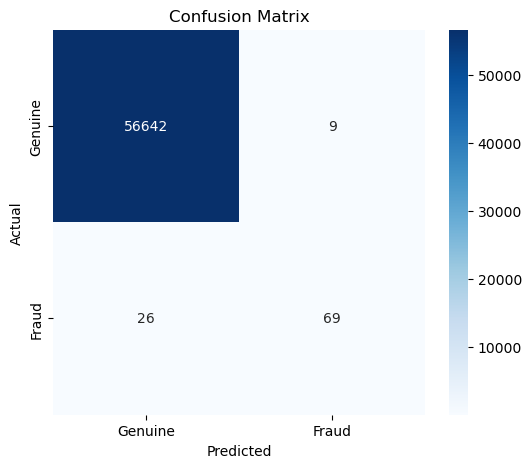

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [5]:
print(classification_report(y_test, y_pred, target_names=["Genuine", "Fraud"]))

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.88      0.73      0.80        95

    accuracy                           1.00     56746
   macro avg       0.94      0.86      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [6]:
evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Score": [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        average_precision_score(y_test, y_proba)
    ]
})

evaluation_metrics

,Metric,Score
0,Precision,0.884615
1,Recall,0.726316
2,F1 Score,0.797688
3,ROC-AUC,0.963234
4,Average Precision,0.794189


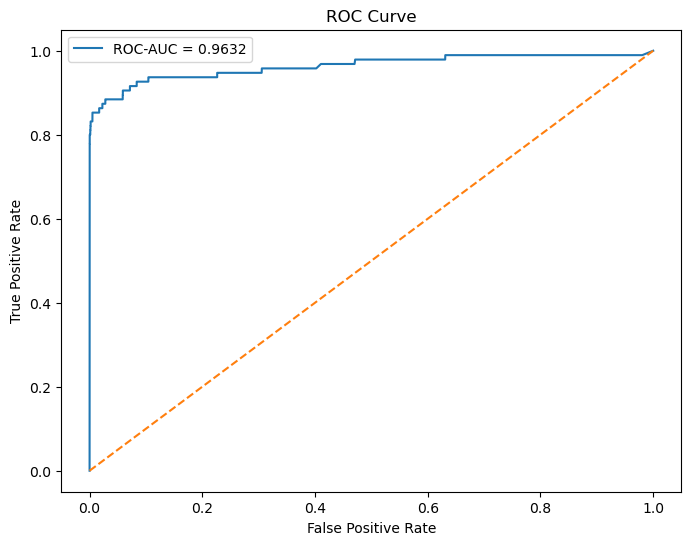

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

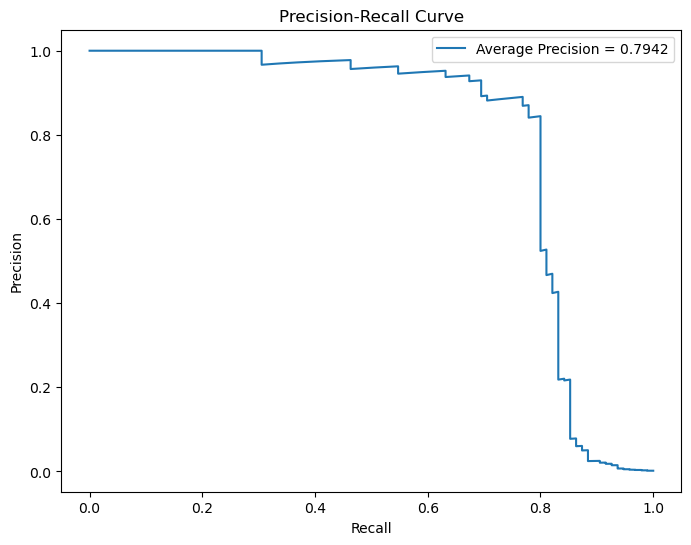

In [8]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Average Precision = {average_precision_score(y_test, y_proba):.4f}")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [9]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.2,0.672566,0.800000,0.730769
1,0.3,0.842697,0.789474,0.815217
2,0.4,0.887500,0.747368,0.811429
3,0.5,0.884615,0.726316,0.797688
4,0.6,0.883117,0.715789,0.790698
5,0.7,0.929577,0.694737,0.795181


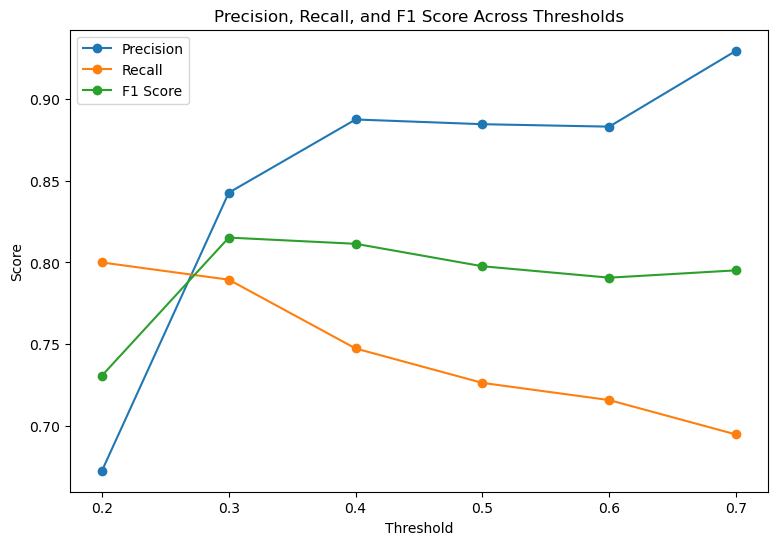

In [10]:
plt.figure(figsize=(9, 6))

plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1 Score"], marker="o", label="F1 Score")

plt.title("Precision, Recall, and F1 Score Across Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [11]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_threshold_row

Threshold    0.300000
Precision    0.842697
Recall       0.789474
F1 Score     0.815217
Name: 1, dtype: float64

In [12]:
best_threshold = best_threshold_row["Threshold"]

y_pred_best_threshold = (y_proba >= best_threshold).astype(int)

print(f"Best Threshold: {best_threshold}")
print(classification_report(y_test, y_pred_best_threshold, target_names=["Genuine", "Fraud"]))

Best Threshold: 0.3
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.84      0.79      0.82        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [13]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X_test_scaled.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    feature_importance.head(10)
else:
    print("This model does not provide feature_importances_.")

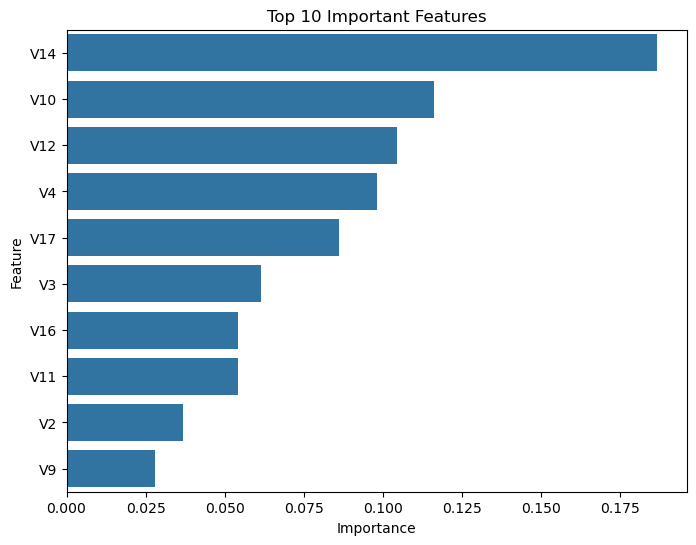

In [14]:
if hasattr(best_model, "feature_importances_"):
    plt.figure(figsize=(8, 6))

    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 10 Important Features")
    plt.show()

In [15]:
evaluation_metrics.to_csv("../data/processed/final_evaluation_metrics.csv", index=False)
threshold_results_df.to_csv("../data/processed/threshold_results.csv", index=False)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.
